# Scattering by $N$ sound-hard spheres via close-evaluation quadrature

Plane wave $u^{inc}(x) = e^{ikz}$ incident on $N$ sound-hard spheres with centers
$C_i = (0,0,z_i)$ on the $z$-axis and radii $a_i$ (axisymmetric configuration).
Total-field formulation: $\Delta u + k^2 u = 0$ outside the spheres,
$\partial u/\partial n = 0$ on each sphere, with the representation

$$u(x) = u^{inc}(x) + \sum_i D_i[u_i](x),$$

where $u_i$ is the trace of the **total** field on sphere $i$ and $D_i$ the
double-layer potential over sphere $i$.  Taking the exterior boundary limit on
sphere $i$ gives the system of boundary integral equations

$$\Big(\tfrac12 I - K_{ii}\Big) u_i \;-\; \sum_{j\neq i} D_j[u_j]\big|_{\partial B_i} \;=\; u^{inc}\big|_{\partial B_i}.$$

Each trace is expanded in the orthonormal axisymmetric basis
$\tilde P_n(\cos\theta_i) = \sqrt{(2n+1)/4\pi}\, P_n(\cos\theta_i) = Y_n^0$
(polar angle $\theta_i$ about center $i$), truncated at $n < N_{basis}$.
Galerkin projection in this basis (carrying the surface measure $a_i^2$) yields
the block system

$$\Big[\, a_i^2\,\mathrm{diag}\big(\lambda_n(a_i)\big)\,\delta_{ij} \;-\; (1-\delta_{ij})\, B_{ij} \,\Big] \, c = b,
\qquad
\lambda_n(a) = -\,i\,(ka)^2\, j_n(ka)\, {h_n^{(1)}}'(ka),$$

where $B_{ij}$ is the Galerkin coupling block $\langle \tilde P_m,\, D_j[\tilde P_n]\rangle_{\partial B_i}$
assembled by the **Carvalho–Khatri–Kim close-evaluation quadrature**
(rotated grid + plane-wave subtraction, `offdiag_bie.coupling_block(..., method='subtract')`),
and $b^i_n = a_i^2\, e^{ikz_i}\, i^n \sqrt{4\pi(2n+1)}\, j_n(ka_i)$ is the
plane-wave trace projected on $\tilde P_n$.

For spheres the exact coupling blocks are available through the multipole identity
$D[\tilde P_n](x) = i k^2 a^2\, j_n'(ka)\, h_n^{(1)}(k|x-C|)\, \tilde P_n(\cos\gamma)$
(`method='exact'`), which serves as ground truth; the subtraction quadrature is
what generalizes to non-spherical shapes.  See `2spheres_offdiag_close_eval.ipynb`
for the study of the off-diagonal blocks themselves.

In [1]:
import time
import numpy as np
import scipy.special as sp
import matplotlib.pyplot as plt

from offdiag_bie import (SphereQuadrature, ptilde, dlp_column_exact,
                         dlp_column_subtract, coupling_block)

t_start = time.time()

## Building blocks

The diagonal operator $\tfrac12 I - K_{ii}$ acts on $\tilde P_n$ as multiplication by
$\lambda_n(a) = -i(ka)^2 j_n(ka)\,{h_n^{(1)}}'(ka)$; by the Wronskian
$j_n h_n' - j_n' h_n = i/x^2$ this equals $1 - i(ka)^2 j_n'(ka) h_n^{(1)}(ka)$ —
both are computed and asserted to agree.

In [2]:
def lambda_n(N, k, a):
    """Symbol of (1/2 I - K) on Ptilde_n for a sound-hard sphere of radius a."""
    n = np.arange(N)
    jn = sp.spherical_jn(n, k * a)
    yn = sp.spherical_yn(n, k * a)
    djn = sp.spherical_jn(n, k * a, derivative=True)
    dyn = sp.spherical_yn(n, k * a, derivative=True)
    lam = -1j * (k * a)**2 * jn * (djn + 1j * dyn)
    lam_wronskian = 1 - 1j * (k * a)**2 * djn * (jn + 1j * yn)
    assert np.max(np.abs(lam - lam_wronskian)) < 1e-12, "Wronskian identity failed"
    return lam


def rhs_block(N, k, a, z):
    """a^2 times the Ptilde_n coefficients of exp(ikz) traced on the sphere at (0,0,z)."""
    n = np.arange(N)
    return a**2 * np.exp(1j * k * z) * (1j)**n * np.sqrt(4 * np.pi * (2 * n + 1)) \
        * sp.spherical_jn(n, k * a)


def assemble(N, k, radii, zs, quad, method='subtract'):
    """Block system A c = b for the total-field traces on all spheres."""
    Ns = len(radii)
    A = np.zeros((Ns * N, Ns * N), dtype=complex)
    b = np.zeros(Ns * N, dtype=complex)
    for i, (ai, zi) in enumerate(zip(radii, zs)):
        A[i*N:(i+1)*N, i*N:(i+1)*N] = ai**2 * np.diag(lambda_n(N, k, ai))
        b[i*N:(i+1)*N] = rhs_block(N, k, ai, zi)
        Ci = np.array([0.0, 0.0, zi])
        for j, (aj, zj) in enumerate(zip(radii, zs)):
            if j == i:
                continue
            Cj = np.array([0.0, 0.0, zj])
            # coupling_block(source = sphere j, target = sphere i); includes a_i^2
            A[i*N:(i+1)*N, j*N:(j+1)*N] = -coupling_block(N, k, aj, Cj, ai, Ci,
                                                          quad, method=method)
    return A, b


def solve(N, k, radii, zs, quad, method='subtract'):
    A, b = assemble(N, k, radii, zs, quad, method)
    c = np.linalg.solve(A, b)
    return [c[i*N:(i+1)*N] for i in range(len(radii))]

## Validation 1 — single sphere against the exact Mie solution

For one sound-hard sphere the total-field trace is known in closed form:
$$u|_{r=a} = \sum_n i^n \sqrt{4\pi(2n+1)}\,\Big[j_n(ka) - \frac{j_n'(ka)}{{h_n^{(1)}}'(ka)} h_n^{(1)}(ka)\Big]\tilde P_n,$$
and by the Wronskian $j_n h_n' - j_n' h_n = i/x^2$ the bracket equals
$\dfrac{i/(ka)^2}{{h_n^{(1)}}'(ka)}$.  Both forms are compared numerically before
being used, then the solved coefficients are checked against them.

In [3]:
def mie_trace_coeffs(N, k, a, z):
    """Exact Ptilde_n coefficients of the total-field trace, single hard sphere at (0,0,z)."""
    n = np.arange(N)
    dhn = sp.spherical_jn(n, k * a, derivative=True) \
        + 1j * sp.spherical_yn(n, k * a, derivative=True)
    return np.exp(1j * k * z) * (1j)**n * np.sqrt(4 * np.pi * (2 * n + 1)) \
        * (1j / (k * a)**2) / dhn


# verify the Wronskian form against j_n - (j_n'/h_n') h_n before trusting it
k1, a1, z1, Nb1 = 2.0, 1.0, 0.3, 12
n = np.arange(Nb1)
jn = sp.spherical_jn(n, k1 * a1)
hn = jn + 1j * sp.spherical_yn(n, k1 * a1)
djn = sp.spherical_jn(n, k1 * a1, derivative=True)
dhn = djn + 1j * sp.spherical_yn(n, k1 * a1, derivative=True)
direct = np.exp(1j * k1 * z1) * (1j)**n * np.sqrt(4 * np.pi * (2 * n + 1)) \
    * (jn - djn / dhn * hn)
err_formula = np.max(np.abs(mie_trace_coeffs(Nb1, k1, a1, z1) - direct))
print(f"Mie coefficient formula vs direct j - (j'/h') h : max abs diff = {err_formula:.3e}")
assert err_formula < 1e-13

quad = SphereQuadrature(24)
c_solved = solve(Nb1, k1, [a1], [z1], quad)[0]
c_exact = mie_trace_coeffs(Nb1, k1, a1, z1)
err_mie = np.max(np.abs(c_solved - c_exact))
print(f"N=1 solved coefficients vs exact Mie trace       : max abs error = {err_mie:.3e}")
assert err_mie < 1e-10, 'single-sphere validation failed'

Mie coefficient formula vs direct j - (j'/h') h : max abs diff = 9.550e-16
N=1 solved coefficients vs exact Mie trace       : max abs error = 8.006e-16


## Validation 2 — two spheres: close-evaluation vs exact coupling blocks

The system is solved twice, once with the off-diagonal blocks assembled by the
close-evaluation quadrature (`method='subtract'`) and once with the analytic
multipole identity (`method='exact'`).  With `SphereQuadrature(24)` and a gap of
$0.5$ the difference should sit at the quadrature floor, well below $10^{-3}$.

In [4]:
radii2, zs2 = [1.0, 0.8], [0.0, 2.3]      # gap = 2.3 - 1.0 - 0.8 = 0.5
c_sub = solve(14, 2.0, radii2, zs2, quad, method='subtract')
c_exa = solve(14, 2.0, radii2, zs2, quad, method='exact')
err_2sph = max(np.max(np.abs(cs - ce)) for cs, ce in zip(c_sub, c_exa))
print(f"N=2 (gap 0.5): subtract vs exact coupling blocks : max abs diff = {err_2sph:.3e}")
assert err_2sph < 1e-3

N=2 (gap 0.5): subtract vs exact coupling blocks : max abs diff = 2.911e-11


## Validation 3 — field values against the exact Mie series ($N=1$)

The represented field $u = u^{inc} + D[u_1]$ is compared against the exact Mie
total field
$u(r,\theta) = \sum_n i^n\sqrt{4\pi(2n+1)}\big[j_n(kr) - \frac{j_n'(ka)}{{h_n^{(1)}}'(ka)}h_n^{(1)}(kr)\big]\tilde P_n(\cos\theta)$
at several exterior points.  Away from the surface the exact multipole column is
used (error at the truncation floor); at a point only $0.2a$ off the surface the
close-evaluation column is used, showing its accuracy where naive quadrature
would fail.

In [5]:
def mie_field(N, k, a, z, pts):
    """Exact total field of a single hard sphere at (0,0,z), plane wave exp(ikz)."""
    d = np.atleast_2d(pts) - np.array([0.0, 0.0, z])
    r = np.linalg.norm(d, axis=1)
    n = np.arange(N)
    djn = sp.spherical_jn(n, k * a, derivative=True)
    dhn = djn + 1j * sp.spherical_yn(n, k * a, derivative=True)
    jn_r = sp.spherical_jn(n[None, :], k * r[:, None])
    hn_r = jn_r + 1j * sp.spherical_yn(n[None, :], k * r[:, None])
    amp = np.exp(1j * k * z) * (1j)**n * np.sqrt(4 * np.pi * (2 * n + 1))
    return np.sum(amp * (jn_r - (djn / dhn) * hn_r) * ptilde(N, d[:, 2] / r), axis=1)


Nb, kk = 30, 2.0
C1 = np.array([0.0, 0.0, z1])
far_pts = np.array([[0.0, 0.0, 4.0], [2.5, 0.0, -1.0], [1.5, 0.0, 2.0],
                    [-2.0, 0.0, 0.3], [0.0, 0.0, -3.0]])
u_rep = np.array([np.exp(1j * kk * p[2])
                  + dlp_column_exact(Nb, kk, a1, C1, p) @ mie_trace_coeffs(Nb, kk, a1, z1)
                  for p in far_pts])
u_ref = mie_field(60, kk, a1, z1, far_pts)
err_far = np.max(np.abs(u_rep - u_ref) / np.abs(u_ref))
print(f"N=1 field, far points, exact columns    : max rel error = {err_far:.3e}")
assert err_far < 1e-8

near_pt = C1 + 1.2 * a1 * np.array([np.sin(0.7), 0.0, np.cos(0.7)])   # 0.2a off surface
u_near = np.exp(1j * kk * near_pt[2]) \
    + dlp_column_subtract(Nb, kk, a1, C1, near_pt, quad) @ mie_trace_coeffs(Nb, kk, a1, z1)
u_near_ref = mie_field(60, kk, a1, z1, near_pt[None, :])[0]
err_near = np.abs(u_near - u_near_ref) / np.abs(u_near_ref)
print(f"N=1 field, 0.2a off surface, subtraction: rel error     = {err_near:.3e}")
assert err_near < 1e-2

N=1 field, far points, exact columns    : max rel error = 6.644e-15
N=1 field, 0.2a off surface, subtraction: rel error     = 1.412e-07


## Demo — three sound-hard spheres

$k = 2$, radii $[1.0,\ 0.7,\ 1.2]$ at $z = [0,\ 2.0,\ 4.4]$ (surface gaps of
$0.3$ and $0.5$), $N_{basis} = 14$, `SphereQuadrature(24)`.  The off-diagonal
blocks use the close-evaluation quadrature.

In [6]:
k = 2.0
radii = [1.0, 0.7, 1.2]
zs = [0.0, 2.0, 4.4]
Nbasis = 14
centers = [np.array([0.0, 0.0, z]) for z in zs]
for (a_l, z_l), (a_r, z_r) in zip(zip(radii, zs), list(zip(radii, zs))[1:]):
    assert z_r - z_l > a_l + a_r, "spheres overlap"

t0 = time.time()
coeffs = solve(Nbasis, k, radii, zs, quad, method='subtract')
print(f"3-sphere system solved ({len(radii) * Nbasis} unknowns) in {time.time() - t0:.1f} s")
tail = max(np.abs(c[-1]) / np.abs(c[0]) for c in coeffs)
print(f"largest relative magnitude of the last retained coefficient: {tail:.1e}")

3-sphere system solved (42 unknowns) in 0.1 s
largest relative magnitude of the last retained coefficient: 1.4e-04


## Total field in the $x$–$z$ plane

The configuration is axisymmetric, so this slice shows everything.  At each grid
point outside all spheres, $u = e^{ikz} + \sum_i D_i[\tilde P_n](x)\, c^i$.  For
spheres the exact multipole columns exist at any distance, but the **subtraction
quadrature is what generalizes to other shapes**; it is therefore used in the
near-surface band (within $0.5\,a_i$ of sphere $i$'s surface) where naive
quadrature would fail, and the fast exact columns elsewhere.  Points inside any
sphere are masked.

In [7]:
def total_field(pts, band=0.5):
    pts = np.atleast_2d(pts)
    u = np.exp(1j * k * pts[:, 2]).astype(complex)
    for x_idx, x in enumerate(pts):
        dists = [np.linalg.norm(x - C) - a for a, C in zip(radii, centers)]
        if min(dists) < 0:                          # inside a sphere
            u[x_idx] = np.nan
            continue
        for i, (a, C) in enumerate(zip(radii, centers)):
            if dists[i] < band * a:
                col = dlp_column_subtract(Nbasis, k, a, C, x, quad)
            else:
                col = dlp_column_exact(Nbasis, k, a, C, x)
            u[x_idx] += col @ coeffs[i]
    return u


nx, nz = 180, 220
xg = np.linspace(-3.5, 3.5, nx)
zg = np.linspace(-3.0, 8.0, nz)
X, Z = np.meshgrid(xg, zg)                          # (nz, nx)
pts = np.column_stack([X.ravel(), np.zeros(X.size), Z.ravel()])
t0 = time.time()
U = total_field(pts).reshape(nz, nx)
print(f"field on {nx} x {nz} grid computed in {time.time() - t0:.1f} s")

field on 180 x 220 grid computed in 12.8 s


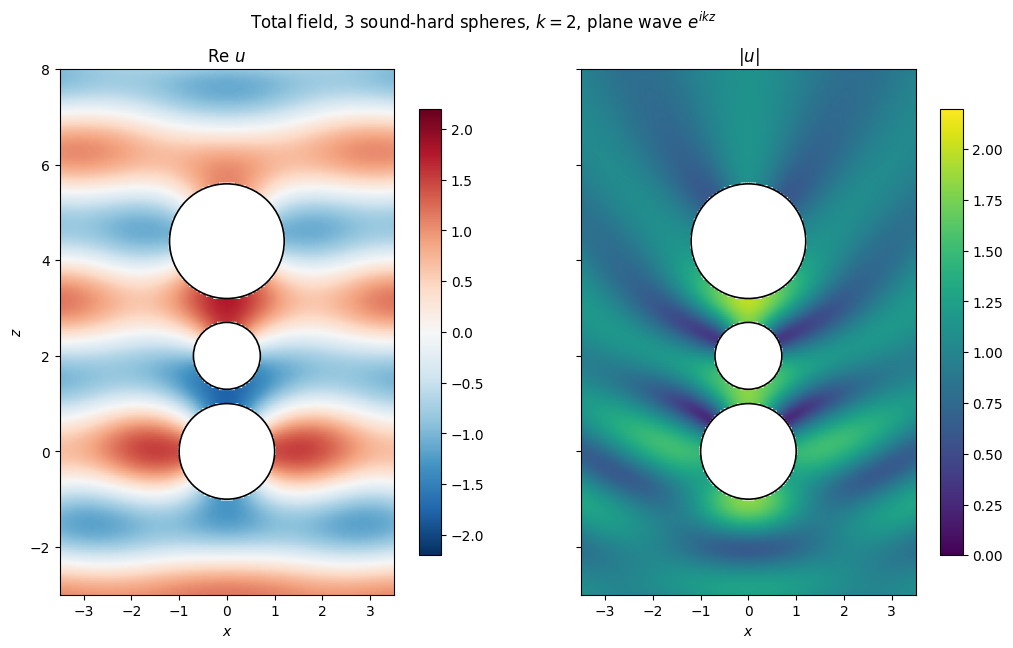

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 6.5), sharey=True)
for ax, F, cmap, ttl, (vmin, vmax) in [
        (axes[0], np.real(U), 'RdBu_r', 'Re $u$', (-2.2, 2.2)),
        (axes[1], np.abs(U), 'viridis', '$|u|$', (0.0, 2.2))]:
    pc = ax.pcolormesh(X, Z, F, cmap=cmap, vmin=vmin, vmax=vmax,
                       shading='gouraud', rasterized=True)
    for a, z in zip(radii, zs):
        ax.add_patch(plt.Circle((0, z), a, fill=False, color='k', lw=1.2))
    ax.set_aspect('equal')
    ax.set_xlabel('$x$')
    ax.set_title(ttl)
    fig.colorbar(pc, ax=ax, shrink=0.85)
axes[0].set_ylabel('$z$')
fig.suptitle(f'Total field, {len(radii)} sound-hard spheres, $k = {k:g}$, '
             'plane wave $e^{ikz}$', y=0.98)
fig.tight_layout()
plt.show()

## $|u|$ on the axis in the gaps between spheres

These segments run right through the near-surface bands of both neighbouring
spheres — exactly where close evaluation matters most.  Every point here is
evaluated with the subtraction quadrature for the adjacent spheres.

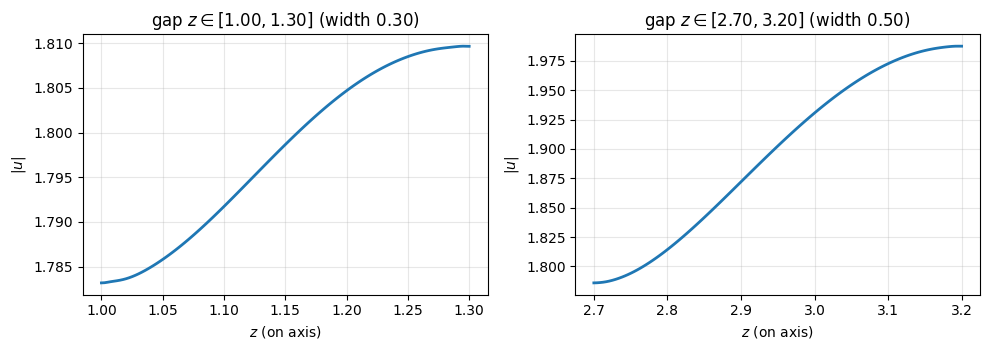

total notebook runtime: 13.7 s


In [9]:
gaps = [(zs[i] + radii[i], zs[i + 1] - radii[i + 1]) for i in range(len(zs) - 1)]
fig, axes = plt.subplots(1, len(gaps), figsize=(10, 3.6))
for ax, (zlo, zhi) in zip(np.atleast_1d(axes), gaps):
    zline = np.linspace(zlo + 1e-6, zhi - 1e-6, 120)
    pline = np.column_stack([np.zeros_like(zline)] * 2 + [zline])
    uline = total_field(pline)
    ax.plot(zline, np.abs(uline), lw=2)
    ax.set_xlabel('$z$ (on axis)')
    ax.set_ylabel('$|u|$')
    ax.set_title(f'gap $z \\in [{zlo:.2f}, {zhi:.2f}]$ (width {zhi - zlo:.2f})')
    ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

print(f"total notebook runtime: {time.time() - t_start:.1f} s")